In [5]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score,
    classification_report,
    confusion_matrix
)
import mlflow
import mlflow.sklearn
import mlflow.xgboost
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully")

Libraries loaded successfully


In [6]:
# Load processed data saved by feature engineering notebook
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test  = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test  = pd.read_csv('../data/processed/y_test.csv').squeeze()

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train fraud %: {y_train.mean()*100:.1f}%")
print(f"y_test  fraud %: {y_test.mean()*100:.1f}%")

X_train: (454902, 30)
X_test:  (56962, 30)
y_train fraud %: 50.0%
y_test  fraud %: 0.2%


In [7]:
# Connect to MLflow server
mlflow.set_tracking_uri("http://localhost:5000")

# Create experiment
mlflow.set_experiment("fraud-detection")

print("MLflow tracking URI:", mlflow.get_tracking_uri())
print("Experiment set: fraud-detection")

MLflow tracking URI: http://localhost:5000
Experiment set: fraud-detection


In [8]:
with mlflow.start_run(run_name="logistic_regression"):
    
    # Train
    lr = LogisticRegression(max_iter=1000, random_state=42)
    lr.fit(X_train, y_train)
    
    # Predict probabilities
    y_pred_proba = lr.predict_proba(X_test)[:, 1]
    
    # Metrics
    pr_auc = average_precision_score(y_test, y_pred_proba)
    
    # Log to MLflow
    mlflow.log_param("model", "LogisticRegression")
    mlflow.log_param("max_iter", 1000)
    mlflow.log_metric("pr_auc", pr_auc)
    mlflow.sklearn.log_model(lr, "model")
    
    print(f"PR-AUC: {pr_auc:.4f}")
    print(classification_report(y_test, lr.predict(X_test)))










PR-AUC: 0.7201
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962



In [9]:
with mlflow.start_run(run_name="random_forest"):
    
    # Train
    rf = RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    )
    rf.fit(X_train, y_train)
    
    # Predict probabilities
    y_pred_proba = rf.predict_proba(X_test)[:, 1]
    
    # Metrics
    pr_auc = average_precision_score(y_test, y_pred_proba)
    
    # Log to MLflow
    mlflow.log_param("model", "RandomForest")
    mlflow.log_param("n_estimators", 100)
    mlflow.log_metric("pr_auc", pr_auc)
    mlflow.sklearn.log_model(rf, "model")
    
    print(f"PR-AUC: {pr_auc:.4f}")
    print(classification_report(y_test, rf.predict(X_test)))

PR-AUC: 0.8578
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.85      0.81      0.83        98

    accuracy                           1.00     56962
   macro avg       0.92      0.90      0.91     56962
weighted avg       1.00      1.00      1.00     56962



In [10]:
with mlflow.start_run(run_name="xgboost"):
    
    # Train
    xgb = XGBClassifier(
        n_estimators=100,
        random_state=42,
        eval_metric='aucpr',
        n_jobs=-1
    )
    xgb.fit(X_train, y_train)
    
    # Predict probabilities
    y_pred_proba = xgb.predict_proba(X_test)[:, 1]
    
    # Metrics
    pr_auc = average_precision_score(y_test, y_pred_proba)
    
    # Log to MLflow
    mlflow.log_param("model", "XGBoost")
    mlflow.log_param("n_estimators", 100)
    mlflow.log_metric("pr_auc", pr_auc)
    mlflow.xgboost.log_model(xgb, "model")
    
    print(f"PR-AUC: {pr_auc:.4f}")
    print(classification_report(y_test, xgb.predict(X_test)))

PR-AUC: 0.8698
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.70      0.87      0.78        98

    accuracy                           1.00     56962
   macro avg       0.85      0.93      0.89     56962
weighted avg       1.00      1.00      1.00     56962



In [11]:
from mlflow.tracking import MlflowClient

client = MlflowClient()

# Get the best run (XGBoost)
experiment = client.get_experiment_by_name("fraud-detection")
runs = client.search_runs(
    experiment_ids=experiment.experiment_id,
    order_by=["metrics.pr_auc DESC"]
)

best_run = runs[0]
print(f"Best run: {best_run.info.run_name}")
print(f"Best PR-AUC: {best_run.data.metrics['pr_auc']:.4f}")
print(f"Run ID: {best_run.info.run_id}")

# Register model
model_uri = f"runs:/{best_run.info.run_id}/model"
mv = mlflow.register_model(model_uri, "fraud-detection-model")
print(f"\nModel registered: {mv.name} version {mv.version}")

Registered model 'fraud-detection-model' already exists. Creating a new version of this model...
2026/05/06 16:03:22 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: fraud-detection-model, version 2


Best run: xgboost
Best PR-AUC: 0.8698
Run ID: 3668a80da7494429982aa6857ed544e1

Model registered: fraud-detection-model version 2


Created version '2' of model 'fraud-detection-model'.


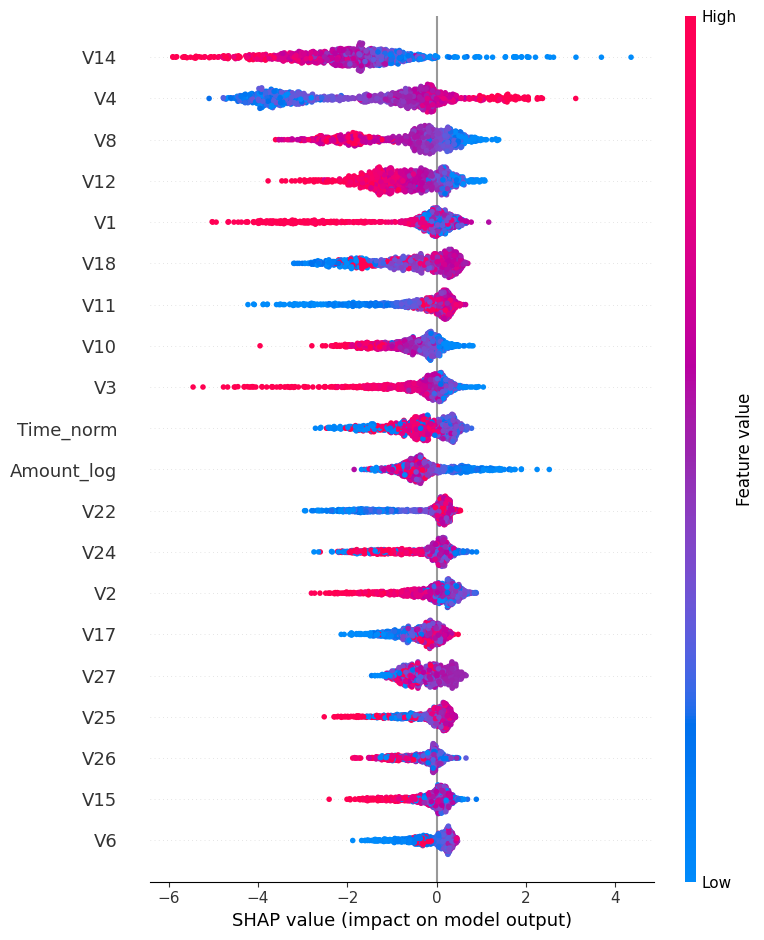

SHAP summary plot saved


In [12]:
import shap

# Use a sample of test data (SHAP is slow on full dataset)
X_test_sample = X_test.sample(1000, random_state=42)

# Create SHAP explainer
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test_sample)

# Summary plot
shap.summary_plot(shap_values, X_test_sample, show=False)
import matplotlib.pyplot as plt
plt.savefig('../reports/shap_summary.png', bbox_inches='tight')
plt.show()
print("SHAP summary plot saved")